# Single-Run Evaluation Analysis

Coverage by schema for each dataset, broken down by generation model.

**Source:** `outputs/evaluation/single_run/{evaluator}/{generator}/{dataset}/evaluation.json`

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "pyproject.toml").exists() else _cwd.parent
SINGLE_RUN_DIR = ROOT / "outputs" / "evaluation" / "single_run"
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="paper", style="ticks")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def latex_escape(s):
    return s.replace("$", "\\$").replace("%", "\\%").replace("±", "$\\pm$")

In [2]:
METHOD_NAMES = {
    "baseline_no_pd": "vanilla LLM",
    "baseline": "vanilla LLM + PDH",
    "schematiq": "ScheMatiQ",
    "schematiq_pdh": "ScheMatiQ + PDH",
    "schematize": "schematize",
}
METHOD_ORDER = ["baseline_no_pd", "baseline", "schematiq", "schematiq_pdh", "schematize"]

CASE_NAMES = {
    "pl_age": "Age",
    "pl_medical_errors": "Medical errors",
    "pl_personal_rights": "Personal rights",
}


def fmt_label(name: str) -> str:
    return CASE_NAMES.get(name, name)

## Load data

In [3]:
records = []
for path in sorted(SINGLE_RUN_DIR.glob("**/evaluation.json")):
    dataset   = path.parent.name
    generator = path.parent.parent.name
    evaluator = path.parent.parent.parent.name
    ed = json.loads(path.read_text())
    for schema in ed["evaluations"]:
        cov = []
        for expert in schema["experts"]:
            t = expert["total_questions"]
            if t:
                cov.append(expert["covered_questions"] / t)
        if cov:
            records.append({
                "evaluator":    evaluator,
                "generator":    generator,
                "dataset":      dataset,
                "schema_index": schema["schema_index"],
                "num_fields":   schema["num_fields"],
                "coverage":     float(np.mean(cov)),
            })

df = pd.DataFrame(records)
print(
    f"{len(df)} schema evaluations · "
    f"{df['dataset'].nunique()} dataset(s) · "
    f"{df['generator'].nunique()} generator model(s)"
)

189 schema evaluations · 3 dataset(s) · 7 generator model(s)


## Table — coverage by schema

In [4]:
table = (
    df[["dataset", "generator", "schema_index", "num_fields", "coverage"]]
    .sort_values(["dataset", "generator", "schema_index"])
    .reset_index(drop=True)
)
table.index += 1

latex = (
    table
    .assign(
        coverage=lambda d: d["coverage"].map("{:.1%}".format).map(latex_escape),
        num_fields=lambda d: d["num_fields"].astype(int),
    )
    .rename(columns={
        "dataset": "Dataset",
        "generator": "Generator",
        "schema_index": "Schema",
        "num_fields": "Fields",
        "coverage": "Coverage",
    })
    .to_latex(index=False, column_format="llcrr")
)
out_tex = FIGURES_DIR / "single_run_coverage_table.tex"


## Figure — coverage by schema

Saved: /home/asawczyn/dev/schematize/outputs/figures/single_run_coverage_by_schema.pdf


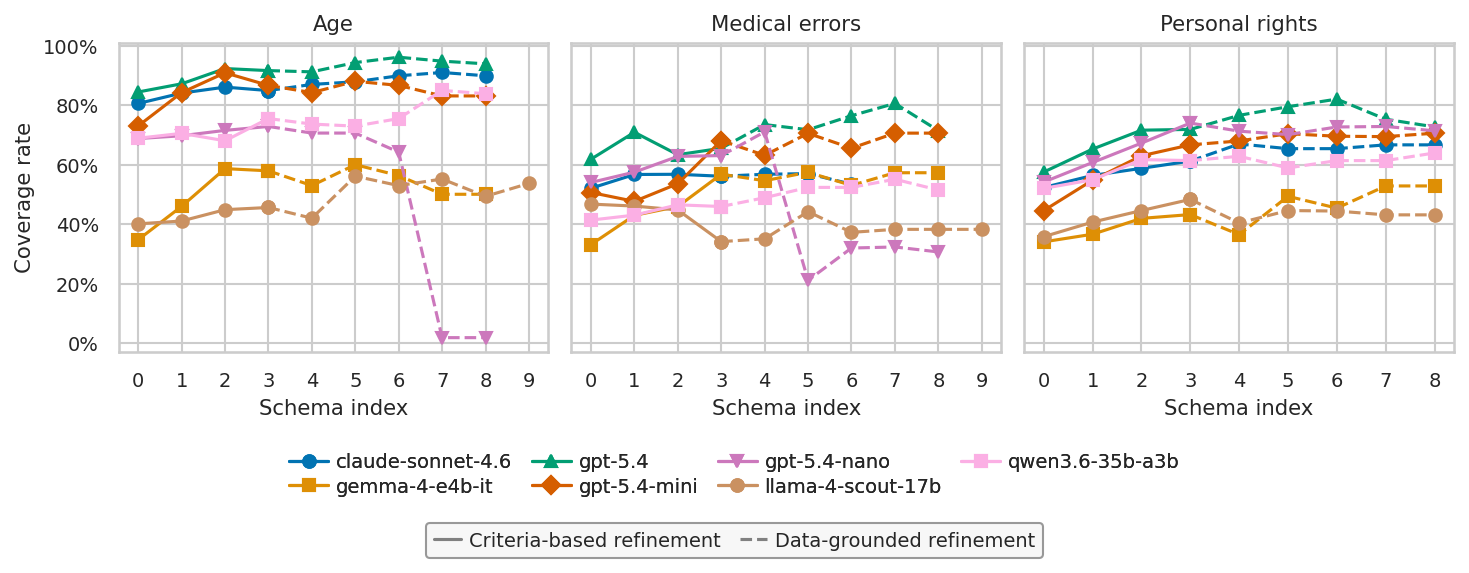

In [5]:
import matplotlib.lines as mlines

datasets   = sorted(df["dataset"].unique())
generators = sorted(df["generator"].unique())

palette    = sns.color_palette("colorblind", n_colors=len(generators))
markers    = ["o", "s", "^", "D", "v"]
color_map  = {g: palette[i % len(palette)] for i, g in enumerate(generators)}
marker_map = {g: markers[i % len(markers)] for i, g in enumerate(generators)}

CRITERIA_BASED_END = 3

col_w = 3.3
ncols = len(datasets)

sns.set_theme(style="whitegrid", font_scale=0.85)

fig, axes = plt.subplots(1, ncols, figsize=(col_w * ncols, 3.0), sharey=True)
if ncols == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    sub = df[df["dataset"] == dataset]
    for gen in generators:
        g = sub[sub["generator"] == gen].sort_values("schema_index")
        kw = dict(marker=marker_map[gen], color=color_map[gen])
        ax.plot(g[g["schema_index"] <= CRITERIA_BASED_END]["schema_index"],
                g[g["schema_index"] <= CRITERIA_BASED_END]["coverage"],
                linestyle="-", label=gen, **kw)
        ax.plot(g[g["schema_index"] >= CRITERIA_BASED_END]["schema_index"],
                g[g["schema_index"] >= CRITERIA_BASED_END]["coverage"],
                linestyle="--", label="_nolegend_", **kw)

    ax.set_title(fmt_label(dataset))
    ax.set_xlabel("Schema index")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

axes[0].set_ylabel("Coverage rate")

gen_handles, gen_labels = axes[0].get_legend_handles_labels()
stage_handles = [
    mlines.Line2D([], [], color="gray", linestyle="-",  label="Criteria-based refinement"),
    mlines.Line2D([], [], color="gray", linestyle="--", label="Data-grounded refinement"),
]

gen_legend = fig.legend(
    gen_handles,
    gen_labels,
    loc="lower center",
    ncol=(len(generators) + 1) // 2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.16),
    handletextpad=0.4,
    columnspacing=1.0,
    labelspacing=0.3,
)
fig.add_artist(gen_legend)
fig.legend(
    stage_handles,
    [h.get_label() for h in stage_handles],
    loc="lower center",
    ncol=2,
    frameon=True,
    fancybox=True,
    facecolor="whitesmoke",
    edgecolor="gray",
    bbox_to_anchor=(0.5, -0.28),
    handlelength=1.4,
    handletextpad=0.4,
    columnspacing=1.0,
    borderpad=0.4,
)
fig.tight_layout()

out_pdf = FIGURES_DIR / "single_run_coverage_by_schema.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
print(f"Saved: {out_pdf}")
plt.show()

## Tables — final coverage (last schema)

In [6]:
import re

BASELINE_EVAL_DIRS = {
    "baseline": ROOT / "outputs" / "baseline_evaluation",
    "baseline_no_pd": ROOT / "outputs" / "baseline_no_pd_evaluation",
}
SCHEMATIQ_EVAL_DIR = ROOT / "outputs" / "schematiq_evaluation"
SCHEMATIQ_RUN_RE = re.compile(r"^schematiq_(?P<generator>.+)_(?P<dialogue>full_dialogue|query_only)$")
SCHEMATIQ_METHOD = {"full_dialogue": "schematiq_pdh", "query_only": "schematiq"}


def schema_coverage(schema):
    cov = [
        e["covered_questions"] / e["total_questions"]
        for e in schema["experts"]
        if e["total_questions"]
    ]
    return float(np.mean(cov)) if cov else None


baseline_records = []
for method, eval_dir in BASELINE_EVAL_DIRS.items():
    for path in sorted(eval_dir.glob("**/evaluation.json")):
        dataset   = path.parent.name
        generator = path.parent.parent.name
        evaluator = path.parent.parent.parent.name
        ed = json.loads(path.read_text())
        for schema in ed["evaluations"]:
            cov = schema_coverage(schema)
            if cov is not None:
                baseline_records.append({
                    "method": method, "evaluator": evaluator,
                    "generator": generator, "dataset": dataset, "coverage": cov,
                })

for path in sorted(SCHEMATIQ_EVAL_DIR.glob("**/evaluation.json")):
    dataset   = path.parent.name
    evaluator = path.parent.parent.parent.name
    m = SCHEMATIQ_RUN_RE.match(path.parent.parent.name)
    generator, method = m["generator"], SCHEMATIQ_METHOD[m["dialogue"]]
    ed = json.loads(path.read_text())
    for schema in ed["evaluations"]:
        cov = schema_coverage(schema)
        if cov is not None:
            baseline_records.append({
                "method": method, "evaluator": evaluator,
                "generator": generator, "dataset": dataset, "coverage": cov,
            })

baseline_df = pd.DataFrame(baseline_records)
print(f"{len(baseline_df)} baseline schema evaluations · {baseline_df['generator'].nunique()} generator(s)")

84 baseline schema evaluations · 7 generator(s)


In [7]:
last_idx = df.groupby(["evaluator", "generator", "dataset"])["schema_index"].transform("max")
final_df = df[df["schema_index"] == last_idx].assign(method="schematize")

combined_df = pd.concat(
    [final_df[["method", "generator", "dataset", "coverage"]], baseline_df[["method", "generator", "dataset", "coverage"]]],
    ignore_index=True,
)

generator_order = (
    combined_df[combined_df["method"] == "schematize"]
    .groupby("generator")["coverage"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)


def fmt_cell(mean, std):
    if pd.isna(mean):
        return "-"
    return f"{mean:.1%} ± {std * 100:.1f}pp" if pd.notna(std) else f"{mean:.1%}"


def format_stats(mean_df, std_df):
    return pd.DataFrame(
        {c: [fmt_cell(m, s) for m, s in zip(mean_df[c], std_df[c])] for c in mean_df.columns},
        index=mean_df.index,
    )


def latex_ranked(values, formatted, higher_better=True, group_level=None):
    """Wrap the best value per row (per group, if given) in textbf, the second-best in underline."""
    out = formatted.copy()
    if group_level is None:
        col_groups = [values.columns]
    else:
        levels = values.columns.get_level_values(group_level)
        col_groups = [values.columns[levels == g] for g in levels.unique()]
    for idx in values.index:
        for cols in col_groups:
            row = values.loc[idx, cols]
            order = sorted(row.dropna().unique(), reverse=higher_better)
            best = order[0] if order else None
            second = order[1] if len(order) > 1 else None
            for col in cols:
                v = row[col]
                if pd.isna(v):
                    continue
                if v == best:
                    out.loc[idx, col] = f"\\textbf{{{out.loc[idx, col]}}}"
                elif v == second:
                    out.loc[idx, col] = f"\\underline{{{out.loc[idx, col]}}}"
    return out

### Detailed (per case)

In [8]:
detail_mean = combined_df.pivot_table(index="generator", columns=["dataset", "method"], values="coverage", aggfunc="mean")

col_order = [(d, m) for d in CASE_NAMES for m in METHOD_ORDER if (d, m) in detail_mean.columns]
detail_mean = detail_mean.loc[generator_order][col_order]

detail_table = detail_mean.map(lambda x: "-" if pd.isna(x) else f"{x:.1%}")
detail_table.columns = pd.MultiIndex.from_tuples([(CASE_NAMES[d], METHOD_NAMES[m]) for d, m in col_order])
detail_table = detail_table.rename_axis("Generator")

display(detail_table)

detail_fmt = detail_mean.map(lambda x: "-" if pd.isna(x) else latex_escape(f"{x:.1%}"))
detail_latex = latex_ranked(detail_mean, detail_fmt, group_level="dataset")
detail_latex.columns = detail_table.columns
detail_latex = detail_latex.rename_axis("Generator")

print(detail_latex.rename_axis([None, None], axis=1).to_latex(column_format="l" + "c" * len(detail_table.columns)))

Age                                              \
                  vanilla LLM vanilla LLM + PDH ScheMatiQ ScheMatiQ + PDH   
Generator                                                                   
gpt-5.4                 49.0%             87.0%     59.3%           84.3%   
gpt-5.4-mini            38.0%             72.7%     15.9%           66.3%   
claude-sonnet-4.6       49.5%             74.9%     82.6%           84.1%   
qwen3.6-35b-a3b         27.9%             54.5%     47.3%           84.0%   
gemma-4-e4b-it           0.0%             55.0%     53.0%           52.0%   
llama-4-scout-17b       25.0%             50.1%     54.2%           55.8%   
gpt-5.4-nano            41.2%             71.5%      9.2%           63.6%   

                             Medical errors                              \
                  schematize    vanilla LLM vanilla LLM + PDH ScheMatiQ   
Generator                                                                 
gpt-5.4                94.0%          25.9%             53.4%     28.1%   
gpt-5.4-mini           83.2%          23.9%             47.9%     31.7%   
claude-sonnet-4.6      89.9%          29.7%             50.1%     27.3%   
qwen3.6-35b-a3b        83.9%          20.2%             50.1%     22.6%   
gemma-4-e4b-it         50.1%           3.4%             26.9%     16.6%   
llama-4-scout-17b      53.7%           9.2%             32.7%     16.8%   
gpt-5.4-nano            1.9%          20.0%             52.3%     26.1%   

                                             Personal rights  \
                  ScheMatiQ + PDH schematize     vanilla LLM   
Generator                                                      
gpt-5.4                     57.2%      71.5%           33.9%   
gpt-5.4-mini                54.1%      70.6%           33.3%   
claude-sonnet-4.6           57.2%      53.5%           32.1%   
qwen3.6-35b-a3b             54.0%      51.5%           37.5%   
gemma-4-e4b-it              43.2%      57.3%            7.9%   
llama-4-scout-17b           35.6%      38.3%           48.8%   
gpt-5.4-nano                22.8%      30.7%            5.5%   

                                                                          
                  vanilla LLM + PDH ScheMatiQ ScheMatiQ + PDH schematize  
Generator                                                                 
gpt-5.4                       52.5%     43.9%           51.2%      72.8%  
gpt-5.4-mini                  46.0%     24.1%           52.4%      70.6%  
claude-sonnet-4.6             56.4%     38.8%           59.9%      66.7%  
qwen3.6-35b-a3b               50.2%     51.4%           63.5%      64.0%  
gemma-4-e4b-it                32.8%     33.9%           44.4%      52.9%  
llama-4-scout-17b             43.2%     27.3%           44.4%      43.2%  
gpt-5.4-nano                  55.6%     36.6%           41.0%      71.4%

\begin{tabular}{lccccccccccccccc}
\toprule
 & \multicolumn{5}{r}{Age} & \multicolumn{5}{r}{Medical errors} & \multicolumn{5}{r}{Personal rights} \\
 & vanilla LLM & vanilla LLM + PDH & ScheMatiQ & ScheMatiQ + PDH & schematize & vanilla LLM & vanilla LLM + PDH & ScheMatiQ & ScheMatiQ + PDH & schematize & vanilla LLM & vanilla LLM + PDH & ScheMatiQ & ScheMatiQ + PDH & schematize \\
Generator &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
gpt-5.4 & 49.0\% & \underline{87.0\%} & 59.3\% & 84.3\% & \textbf{94.0\%} & 25.9\% & 53.4\% & 28.1\% & \underline{57.2\%} & \textbf{71.5\%} & 33.9\% & \underline{52.5\%} & 43.9\% & 51.2\% & \textbf{72.8\%} \\
gpt-5.4-mini & 38.0\% & \underline{72.7\%} & 15.9\% & 66.3\% & \textbf{83.2\%} & 23.9\% & 47.9\% & 31.7\% & \underline{54.1\%} & \textbf{70.6\%} & 33.3\% & 46.0\% & 24.1\% & \underline{52.4\%} & \textbf{70.6\%} \\
claude-sonnet-4.6 & 49.5\% & 74.9\% & 82.6\% & \underline{84.1\%} & \textbf{89.9\%} & 29.7\% & 50.1\% & 27.3\% & \textbf{57.2\%

### Summary (avg)

In [9]:
per_case = combined_df.pivot_table(index=["generator", "method"], columns="dataset", values="coverage")
summary_mean = per_case.mean(axis=1).unstack("method")
summary_std = per_case.std(axis=1).unstack("method")

method_cols = [m for m in METHOD_ORDER if m in summary_mean.columns]
summary_mean = summary_mean.loc[generator_order][method_cols]
summary_std = summary_std.loc[generator_order][method_cols]

summary_table = format_stats(summary_mean, summary_std)
summary_table.columns = [METHOD_NAMES[m] for m in method_cols]
summary_table = summary_table.rename_axis("Generator")

display(summary_table)

summary_fmt = format_stats(summary_mean, summary_std).map(latex_escape)
summary_latex = latex_ranked(summary_mean, summary_fmt)
summary_latex.columns = summary_table.columns
summary_latex = summary_latex.rename_axis("Generator")

print(summary_latex.to_latex(column_format="l" + "c" * len(summary_table.columns)))

,vanilla LLM,vanilla LLM + PDH,ScheMatiQ,ScheMatiQ + PDH,schematize
Generator,,,,,
gpt-5.4,36.3% ± 11.7pp,64.3% ± 19.7pp,43.8% ± 15.6pp,64.3% ± 17.6pp,79.4% ± 12.6pp
gpt-5.4-mini,31.7% ± 7.2pp,55.5% ± 14.9pp,23.9% ± 7.9pp,57.6% ± 7.6pp,74.8% ± 7.2pp
claude-sonnet-4.6,37.1% ± 10.8pp,60.5% ± 12.9pp,49.6% ± 29.2pp,67.1% ± 14.8pp,70.0% ± 18.5pp
qwen3.6-35b-a3b,28.5% ± 8.7pp,51.6% ± 2.5pp,40.4% ± 15.6pp,67.2% ± 15.3pp,66.5% ± 16.3pp
gemma-4-e4b-it,3.8% ± 4.0pp,38.2% ± 14.8pp,34.5% ± 18.2pp,46.5% ± 4.8pp,53.4% ± 3.7pp
llama-4-scout-17b,27.7% ± 20.0pp,42.0% ± 8.8pp,32.7% ± 19.3pp,45.3% ± 10.1pp,45.1% ± 7.9pp
gpt-5.4-nano,22.2% ± 18.0pp,59.8% ± 10.3pp,24.0% ± 13.8pp,42.5% ± 20.4pp,34.7% ± 35.0pp


\begin{tabular}{lccccc}
\toprule
 & vanilla LLM & vanilla LLM + PDH & ScheMatiQ & ScheMatiQ + PDH & schematize \\
Generator &  &  &  &  &  \\
\midrule
gpt-5.4 & 36.3\% $\pm$ 11.7pp & \underline{64.3\% $\pm$ 19.7pp} & 43.8\% $\pm$ 15.6pp & 64.3\% $\pm$ 17.6pp & \textbf{79.4\% $\pm$ 12.6pp} \\
gpt-5.4-mini & 31.7\% $\pm$ 7.2pp & 55.5\% $\pm$ 14.9pp & 23.9\% $\pm$ 7.9pp & \underline{57.6\% $\pm$ 7.6pp} & \textbf{74.8\% $\pm$ 7.2pp} \\
claude-sonnet-4.6 & 37.1\% $\pm$ 10.8pp & 60.5\% $\pm$ 12.9pp & 49.6\% $\pm$ 29.2pp & \underline{67.1\% $\pm$ 14.8pp} & \textbf{70.0\% $\pm$ 18.5pp} \\
qwen3.6-35b-a3b & 28.5\% $\pm$ 8.7pp & 51.6\% $\pm$ 2.5pp & 40.4\% $\pm$ 15.6pp & \textbf{67.2\% $\pm$ 15.3pp} & \underline{66.5\% $\pm$ 16.3pp} \\
gemma-4-e4b-it & 3.8\% $\pm$ 4.0pp & 38.2\% $\pm$ 14.8pp & 34.5\% $\pm$ 18.2pp & \underline{46.5\% $\pm$ 4.8pp} & \textbf{53.4\% $\pm$ 3.7pp} \\
llama-4-scout-17b & 27.7\% $\pm$ 20.0pp & 42.0\% $\pm$ 8.8pp & 32.7\% $\pm$ 19.3pp & \textbf{45.3\% $\pm$ 10.1pp} & \un

## Figure — coverage by method (bar plots)

/tmp/ipykernel_622067/3800403260.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([wrap_label(g) for g in generator_order])


Saved: /home/asawczyn/dev/schematize/outputs/figures/coverage_by_method_bars.pdf


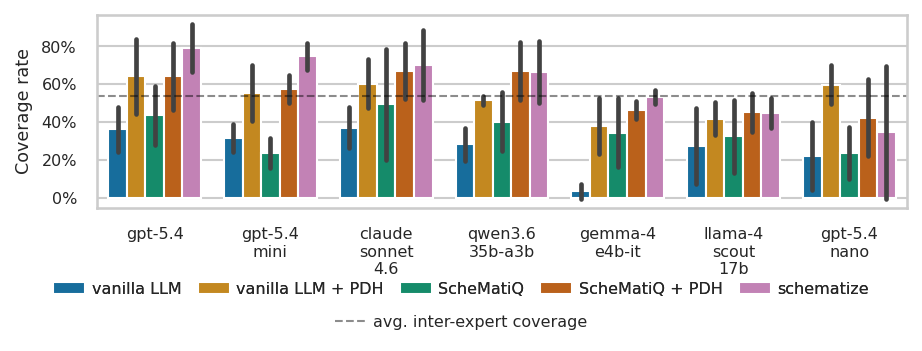

In [10]:
def wrap_label(name: str, max_len: int = 8) -> str:
    parts = name.split("-")
    lines, cur = [], ""
    for p in parts:
        if cur and len(cur) + 1 + len(p) > max_len:
            lines.append(cur)
            cur = p
        else:
            cur = f"{cur}-{p}" if cur else p
    lines.append(cur)
    return "\n".join(lines)


INTER_EXPERT_COVERAGE = 0.538

plot_df = combined_df.assign(Method=combined_df["method"].map(METHOD_NAMES))
methods = [m for m in METHOD_ORDER if m in combined_df["method"].unique()]
hue_order = [METHOD_NAMES[m] for m in methods]
palette = sns.color_palette("colorblind", n_colors=len(hue_order))

sns.set_theme(style="whitegrid", font_scale=0.70)
fig, ax = plt.subplots(figsize=(0.6 * len(generator_order) + 2, 2))
sns.barplot(
    data=plot_df, x="generator", y="coverage", hue="Method",
    order=generator_order, hue_order=hue_order, errorbar="sd",
    palette=palette, ax=ax,
)
ax.axhline(INTER_EXPERT_COVERAGE, color="black", linestyle="--", linewidth=1, alpha=0.45, label="avg. inter-expert coverage")
ax.set_xticklabels([wrap_label(g) for g in generator_order])
ax.set_xlabel("")
ax.set_ylabel("Coverage rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
method_legend = fig.legend(
    handles[:-1],
    labels[:-1],
    loc="lower center",
    ncol=len(hue_order),
    frameon=False,
    bbox_to_anchor=(0.5, -0.05),
    handletextpad=0.4,
    columnspacing=1.0,
    labelspacing=0.3,
)
fig.add_artist(method_legend)
fig.legend(
    handles[-1:],
    labels[-1:],
    loc="lower center",
    ncol=1,
    frameon=False,
    bbox_to_anchor=(0.5, -0.16),
    handletextpad=0.4,
)
fig.tight_layout()

out_pdf = FIGURES_DIR / "coverage_by_method_bars.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
print(f"Saved: {out_pdf}")
plt.show()

## Table — cost analysis per generation

In [11]:
# "baseline" (vanilla LLM + PDH) used a different, unmeasured protocol, so its
# cost is unknown and it is excluded here rather than reported inaccurately.
COST_DIRS = {
    "schematize":     ROOT / "outputs" / "generated_schemas",
    "baseline_no_pd": ROOT / "outputs" / "baseline_no_pd",
}
SCHEMATIQ_GEN_DIR = ROOT / "outputs" / "schematiq"

PRICING = {
    "gpt-5.4":           (2.50,  0.250, 15.00),
    "gpt-5.4-mini":      (0.75,  0.075,  4.50),
    "gpt-5.4-nano":      (0.20,  0.020,  1.25),
    "claude-sonnet-4.6": (3.00,  0.300, 15.00),
    "llama-4-scout-17b": (0.10,  0.10,   0.30),
    "qwen3.6-35b-a3b":   (0.14,  0.14,   1.00),
    "gemma-4-e4b-it":    (0.20,  0.20,   0.10),
}


def state_cost(state, generator):
    usage     = state.get("token_usage", [])
    in_tok    = sum(u["input_tokens"]  for u in usage)
    out_tok   = sum(u["output_tokens"] for u in usage)
    cache_tok = sum(u.get("input_token_details", {}).get("cache_read", 0) for u in usage)
    price     = PRICING.get(generator)
    if not (price and usage):
        return None
    p_in, p_cache, p_out = price
    return ((in_tok - cache_tok) * p_in + cache_tok * p_cache + out_tok * p_out) / 1e6


cost_records = []
for method, base_dir in COST_DIRS.items():
    for p in sorted(base_dir.glob("*/*/state.json")):
        generator = p.parent.parent.name
        dataset   = p.parent.name
        state     = json.loads(p.read_text())
        cost_records.append({
            "method":    method,
            "generator": generator,
            "dataset":   dataset,
            "cost_usd":  state_cost(state, generator),
        })

for p in sorted(SCHEMATIQ_GEN_DIR.glob("*/*/state.json")):
    dataset = p.parent.name
    m = SCHEMATIQ_RUN_RE.match(p.parent.parent.name)
    generator, method = m["generator"], SCHEMATIQ_METHOD[m["dialogue"]]
    if method == "schematiq_pdh":
        continue
    state = json.loads(p.read_text())
    cost_records.append({
        "method":    method,
        "generator": generator,
        "dataset":   dataset,
        "cost_usd":  state_cost(state, generator),
    })

cost_df = pd.DataFrame(cost_records)

# Rate (coverage / cost) is only meaningful for schematize: the baselines'
# cost is either unknown (PDH) or not a fair basis for a cost-efficiency metric.
rate_df = (
    combined_df[combined_df["method"] == "schematize"]
    .merge(cost_df, on=["method", "generator", "dataset"])
    .assign(rate=lambda d: d["coverage"] / d["cost_usd"])
)


def pivot_stats_table(data, value_col, fmt):
    mean = data.pivot_table(index="generator", columns="method", values=value_col, aggfunc="mean")
    std  = data.pivot_table(index="generator", columns="method", values=value_col, aggfunc="std")
    method_cols = [m for m in METHOD_ORDER if m in mean.columns]
    order = [g for g in generator_order if g in mean.index]
    mean, std = mean.loc[order, method_cols], std.loc[order, method_cols]
    table = pd.DataFrame(
        {c: [fmt(m, s) for m, s in zip(mean[c], std[c])] for c in mean.columns},
        index=mean.index,
    )
    table.columns = [METHOD_NAMES[m] for m in method_cols]
    return table.rename_axis("Generator")


cost_table = pivot_stats_table(
    cost_df, "cost_usd", lambda m, s: f"${m:.3f} ± {s:.3f}" if pd.notna(m) else "-"
)
rate_table = pivot_stats_table(
    rate_df, "rate", lambda m, s: f"{m:.2f} ± {s:.2f}" if pd.notna(m) else "-"
)

print("Cost (USD)")
display(cost_table)
print(cost_table.map(latex_escape).to_latex(column_format="l" + "c" * len(cost_table.columns)))

print("Rate (coverage / USD)")
display(rate_table)
print(rate_table.map(latex_escape).to_latex(column_format="l" + "c" * len(rate_table.columns)))

Cost (USD)


,vanilla LLM,ScheMatiQ,schematize
Generator,,,
gpt-5.4,$0.024 ± 0.008,$0.176 ± 0.076,$3.785 ± 0.312
gpt-5.4-mini,$0.005 ± 0.000,$0.044 ± 0.020,$0.828 ± 0.059
claude-sonnet-4.6,$0.027 ± 0.006,$0.243 ± 0.086,$3.057 ± 0.510
qwen3.6-35b-a3b,$0.005 ± 0.001,$0.033 ± 0.007,$0.183 ± 0.010
gemma-4-e4b-it,$0.000 ± 0.000,$0.016 ± 0.001,$0.041 ± 0.001
llama-4-scout-17b,$0.000 ± 0.000,$0.007 ± 0.001,$0.023 ± 0.002
gpt-5.4-nano,$0.002 ± 0.001,$0.014 ± 0.007,$0.234 ± 0.015


\begin{tabular}{lccc}
\toprule
 & vanilla LLM & ScheMatiQ & schematize \\
Generator &  &  &  \\
\midrule
gpt-5.4 & \$0.024 $\pm$ 0.008 & \$0.176 $\pm$ 0.076 & \$3.785 $\pm$ 0.312 \\
gpt-5.4-mini & \$0.005 $\pm$ 0.000 & \$0.044 $\pm$ 0.020 & \$0.828 $\pm$ 0.059 \\
claude-sonnet-4.6 & \$0.027 $\pm$ 0.006 & \$0.243 $\pm$ 0.086 & \$3.057 $\pm$ 0.510 \\
qwen3.6-35b-a3b & \$0.005 $\pm$ 0.001 & \$0.033 $\pm$ 0.007 & \$0.183 $\pm$ 0.010 \\
gemma-4-e4b-it & \$0.000 $\pm$ 0.000 & \$0.016 $\pm$ 0.001 & \$0.041 $\pm$ 0.001 \\
llama-4-scout-17b & \$0.000 $\pm$ 0.000 & \$0.007 $\pm$ 0.001 & \$0.023 $\pm$ 0.002 \\
gpt-5.4-nano & \$0.002 $\pm$ 0.001 & \$0.014 $\pm$ 0.007 & \$0.234 $\pm$ 0.015 \\
\bottomrule
\end{tabular}

Rate (coverage / USD)


,schematize
Generator,
gpt-5.4,0.21 ± 0.05
gpt-5.4-mini,0.90 ± 0.06
claude-sonnet-4.6,0.23 ± 0.02
qwen3.6-35b-a3b,3.62 ± 0.77
gemma-4-e4b-it,13.19 ± 1.07
llama-4-scout-17b,19.89 ± 5.44
gpt-5.4-nano,1.46 ± 1.51


\begin{tabular}{lc}
\toprule
 & schematize \\
Generator &  \\
\midrule
gpt-5.4 & 0.21 $\pm$ 0.05 \\
gpt-5.4-mini & 0.90 $\pm$ 0.06 \\
claude-sonnet-4.6 & 0.23 $\pm$ 0.02 \\
qwen3.6-35b-a3b & 3.62 $\pm$ 0.77 \\
gemma-4-e4b-it & 13.19 $\pm$ 1.07 \\
llama-4-scout-17b & 19.89 $\pm$ 5.44 \\
gpt-5.4-nano & 1.46 $\pm$ 1.51 \\
\bottomrule
\end{tabular}

